In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import pandas as pd
import os
python_exec = sys.executable

## change to examples folder

In [2]:
basedir = 'openevolve/examples/symbolic_regression/'
basedir = 'example_symbolic_regression/'
os.chdir(basedir)

## select a problem

In [3]:
## if you change problem id restart the notebook and run all cells again
problem_id = 'matsci/MatSci18'
problem_id = 'bio_pop_growth/BPG8' 
X_test = np.load(f'problems/{problem_id}/X_test_for_eval.npy')
y_test = np.load(f'problems/{problem_id}/y_test_for_eval.npy')

X_train = np.load(f'problems/{problem_id}/X_train_for_eval.npy')
y_train = np.load(f'problems/{problem_id}/y_train_for_eval.npy')

X_test.shape, y_test.shape, X_train.shape, y_train.shape

((500, 2), (500,), (4000, 2), (4000,))

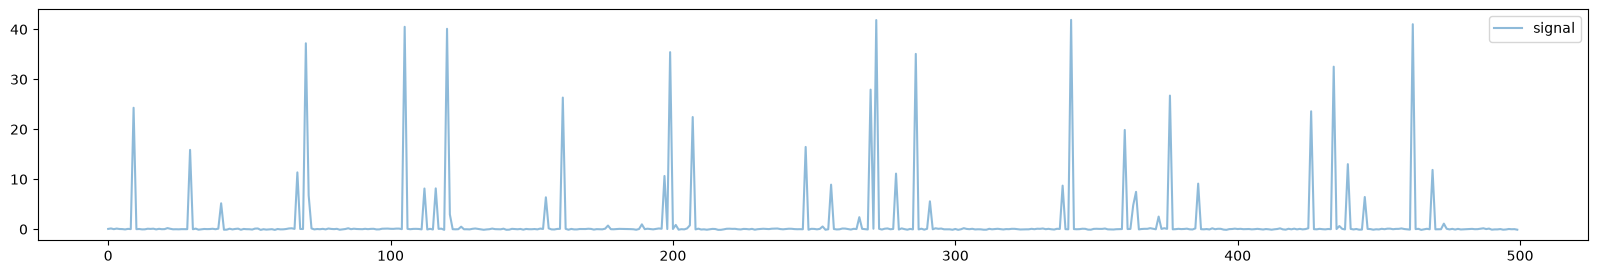

In [4]:
plt.figure(figsize=(20,3))
plt.plot(y_test, alpha=.5, label='signal')
plt.legend()

## run `evaluation.py` with the initial program

In [5]:
%%bash -s "{python_exec}"  "{problem_id}"

python=$1
problem_id=$2

echo "---- WORKING DIR -----"
echo $basedir
echo "---- PYTHON EXEC -----"
echo $python

$python problems/$problem_id/evaluator.py problems/$problem_id/initial_program.py
#$python problems/$problem_id/evaluator.py problems/$problem_id/openevolve_output/best/best_program.py


---- WORKING DIR -----

---- PYTHON EXEC -----
/opt/conda/envs/openevolve/bin/python
Evaluating model: problems/bio_pop_growth/BPG8/initial_program.py
Using NUM_INPUT_FEATURES_EXPECTED = 2
Using MODEL_NUM_PARAMS_EXPECTED = 10
Loading X_train from: /usr/local/google/home/raulramos/projects/openevolve-lab/example_symbolic_regression/problems/bio_pop_growth/BPG8/X_train_for_eval.npy
Loading y_train from: /usr/local/google/home/raulramos/projects/openevolve-lab/example_symbolic_regression/problems/bio_pop_growth/BPG8/y_train_for_eval.npy

Evaluation Results:
  combined_score: -1.6110
  negative_mse: -40.8275


## Optimize the symbolic program function to plot against test data

In [6]:
import importlib

module_evaluator_path = f'problems/{problem_id}/evaluator'
evaluator = importlib.import_module(module_evaluator_path.replace('/','.'))


In [7]:

def get_func(program_path):
  spec = importlib.util.spec_from_file_location("model_program", program_path)
  model_module = importlib.util.module_from_spec(spec)
  spec.loader.exec_module(model_module)
  return model_module.run_search()


def optimize_func_params(func):
  from scipy.optimize import minimize
  initial_params = np.random.rand(10)

  opt_result = minimize(
      evaluator.objective_function,
      initial_params,
      args=(func, X_train, y_train),
      method='BFGS'
  )
  return opt_result.x


In [8]:
initial_program_path = f'problems/{problem_id}/initial_program.py'
best_program_path = f'problems/{problem_id}/openevolve_output/best/best_program.py'

initial_program_func        = get_func(initial_program_path)
initial_program_params      = optimize_func_params(initial_program_func)
initial_program_y_test_pred = initial_program_func(X_test, initial_program_params)
initial_program_train_negative_mse = -np.mean((initial_program_y_test_pred - y_test)**2)
print (f'initial program negative mse {initial_program_train_negative_mse:.4f}')


if os.path.isfile(best_program_path):
  best_program_func        = get_func(best_program_path)
  best_program_params      = optimize_func_params(best_program_func)
  best_program_y_test_pred = best_program_func(X_test, best_program_params)
  best_program_train_negative_mse = -np.mean((best_program_y_test_pred - y_test)**2)
  print (f'best program negative mse {best_program_train_negative_mse:.4f}')



initial program negative mse -37.7452
best program negative mse -0.0003


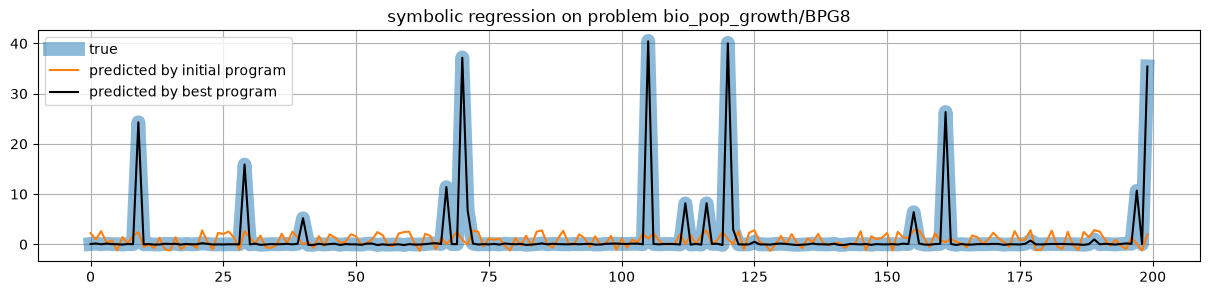

In [9]:
plt.figure(figsize=(15,3))
plt.plot(y_test[:200], alpha=.5, lw=10, label='true')
plt.plot(initial_program_y_test_pred[:200], label='predicted by initial program')
if os.path.isfile(best_program_path):
  plt.plot(best_program_y_test_pred[:200], color='black', label='predicted by best program')

plt.title(f'symbolic regression on problem {problem_id}')
plt.grid()
plt.legend()




## Inspect the best program

In [10]:
!cat {best_program_path}

"""
Initial program: A naive linear model for symbolic regression.
This model predicts the output as a linear combination of input variables
or a constant if no input variables are present.
The function is designed for vectorized input (X matrix).

Target output variable: dP_dt (Population growth rate)
Input variables (columns of x): t (Time), P (Population at time t)
"""
import numpy as np

# Input variable mapping for x (columns of the input matrix):
#   x[:, 0]: t (Time)
#   x[:, 1]: P (Population at time t)

# Parameters will be optimized by BFGS outside this function.
# Number of parameters expected by this model: 10.
# Example initialization: params = np.random.rand(10)

# EVOLVE-BLOCK-START

def func(x, params):
    """
    Models population growth rate dP_dt using a non-autonomous logistic-type model.
    Inputs:
        x[:, 0]: t (Time)
        x[:, 1]: P (Population)
    """
    t, P = x[:, 0], x[:, 1]
    # Combines linear, quadratic (logistic), and time-interaction terms
 